# 09b — SCM, DAG & Counterfactual Analysis (SP4 Part B)

**Task 3.2**: RTB 인과 구조 명세 + DoWhy 추정 + refutation + model-based counterfactual.

## Key Results

| Method | Estimate | Robust? |
|--------|----------|---------|
| Linear Regression (backdoor) | TBD | TBD |
| Propensity Score Weighting | TBD | TBD |
| Refutation (3 tests) | — | TBD |

**Counterfactual**: bid ×0.9 → surplus TBD, bid ×1.1 → surplus TBD

**Core insight**: [실행 후 채움]

**DAG 핵심**: Bid → Surplus의 2-channel 구조
- Volume: bid → win → surplus (positive)
- Cost: bid → payment → surplus (negative)

## Section 0: Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path('.').absolute().parent
sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_PATH = PROJECT_ROOT / 'results'
FIG_PATH = RESULTS_PATH / 'figures'
DATA_PATH = PROJECT_ROOT / 'data' / 'ipinyou' / 'prediction' / 'features'
MODEL_PATH = RESULTS_PATH / 'models'

FIG_PATH.mkdir(parents=True, exist_ok=True)
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})
PALETTE = sns.color_palette('Set2', 8)

from src.causal.scm import (
    build_rtb_dag, estimate_causal_effect, run_refutation_tests,
    simulate_counterfactual, simulate_counterfactual_scenarios,
)
from src.bidding.value import ValueConfig, compute_impression_values
import graphviz

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/taehyun/project/rtb_ipinyou


In [3]:
# --- Data loading (same as 09a) ---
COLS = ['bidprice', 'payprice', 'slotprice', 'adexchange', 'hour', 'region',
        'win', 'click', 'advertiser', 'slot_area', 'domain_freq']
test_df = pd.read_parquet(DATA_PATH / 'test.parquet', columns=COLS)
preds = dict(np.load(MODEL_PATH / 'escm2wc_dr_test_predictions.npz'))

# Filter adv 2997 (no bid variation)
mask = test_df['advertiser'] != 2997
test_filtered = test_df[mask].reset_index(drop=True)
preds_filtered = {k: np.asarray(v)[mask.values] for k, v in preds.items()}

print(f"Test filtered: {len(test_filtered):,} rows")
print(f"Win rate: {test_filtered['win'].mean():.3f}")

Test filtered: 17,388,171 rows
Win rate: 0.208


## Section 1: DAG Visualization & Domain Justification

RTB 인과 구조를 DAG로 명세. 핵심: Bid → Surplus의 2-channel 구조.
- **Volume channel**: bid → win → surplus (winning more auctions)
- **Cost channel**: bid → payment → surplus (paying more per win)

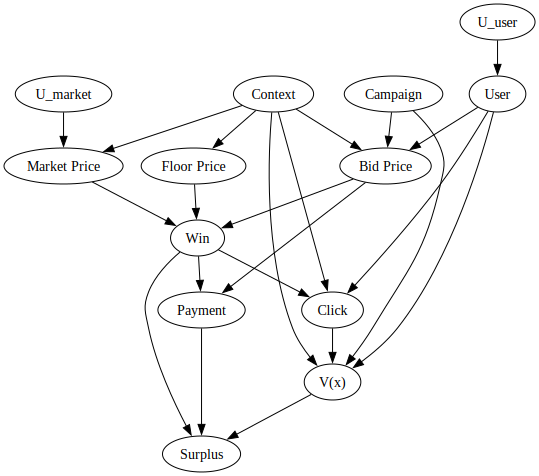


=== Causal Edges ===
Exogenous: U_market → market_price, U_user → user
Bidding:   campaign/context/user → bid
Auction:   bid + market_price + floor → win
Volume:    win → surplus (positive)
Cost:      bid → payment, win → payment, payment → surplus (negative)
Value:     win → click → value → surplus


In [4]:
# --- Figure 1: RTB DAG ---
dag = build_rtb_dag(treatment='bid', outcome='surplus')
src = graphviz.Source(dag.graph_dot)

# Save as PNG
src.render(str(FIG_PATH / '09b_rtb_dag'), format='png', cleanup=True)
display(src)

print("\n=== Causal Edges ===")
print("Exogenous: U_market → market_price, U_user → user")
print("Bidding:   campaign/context/user → bid")
print("Auction:   bid + market_price + floor → win")
print("Volume:    win → surplus (positive)")
print("Cost:      bid → payment, win → payment, payment → surplus (negative)")
print("Value:     win → click → value → surplus")

## Section 2: DoWhy Identification & Estimation

Backdoor criterion으로 인과 효과 식별. bid → surplus 및 bid → win 추정.

In [5]:
# --- DoWhy: bid → surplus ---
print("=== Causal Effect: bid → surplus ===")
scm_surplus = estimate_causal_effect(test_filtered, subsample_n=500_000, preds=preds_filtered)
for method, est in scm_surplus.estimates.items():
    ci = scm_surplus.estimate_cis.get(method)
    ci_str = f" CI=[{ci[0]:.4f}, {ci[1]:.4f}]" if ci else ""
    print(f"  {method}: {est:.4f}{ci_str}")

# --- DoWhy: bid → win ---
print("\n=== Causal Effect: bid → win ===")
dag_win = build_rtb_dag(treatment='bid', outcome='win')
scm_win = estimate_causal_effect(test_filtered, dag=dag_win, subsample_n=500_000)
for method, est in scm_win.estimates.items():
    ci = scm_win.estimate_cis.get(method)
    ci_str = f" CI=[{ci[0]:.4f}, {ci[1]:.4f}]" if ci else ""
    print(f"  {method}: {est:.4f}{ci_str}")

=== Causal Effect: bid → surplus ===
  backdoor.linear_regression: -0.1388 CI=[-0.1600, -0.1159]
  backdoor.propensity_score_weighting: nan

=== Causal Effect: bid → win ===
  backdoor.linear_regression: -0.0036 CI=[-0.0037, -0.0034]
  backdoor.propensity_score_weighting: nan


## Section 3: Refutation Tests

3종 robustness test: (1) random common cause, (2) placebo treatment, (3) data subset.

In [6]:
# --- Refutation tests ---
refutation = run_refutation_tests(test_filtered, subsample_n=500_000, n_simulations=30, preds=preds_filtered)

print(f"Overall robust: {refutation.is_robust}")
for test_name, result in refutation.tests.items():
    print(f"\n{test_name}:")
    for k, v in result.items():
        if isinstance(v, float):
            print(f"  {k}: {v:.4f}")
        else:
            print(f"  {k}: {v}")

Overall robust: True

random_common_cause:
  new_effect: -0.1388
  original_effect: -0.1388
  change_pct: 0.0014

placebo_treatment:
  new_effect: -0.0008

data_subset:
  new_effect: -0.1397


## Section 4: Counterfactual Scenarios (Primary Causal Tool)

Model-based counterfactual: `run_auction_simulation()` 기반.
bid multiplier별 win rate, surplus, overpayment 변화 탐색.

In [7]:
# --- Won-only data for simulation ---
won_mask = test_filtered['win'] == 1
won_df = test_filtered[won_mask].reset_index(drop=True)
won_preds = {k: np.asarray(v)[won_mask.values] for k, v in preds_filtered.items()}

market_prices = won_df['payprice'].values.astype(float)
original_bids = won_df['bidprice'].values.astype(float)
clicks = won_df['click'].values.astype(np.int32)
values = compute_impression_values(won_preds['p_ctr']).values

print(f"Won-only: {len(won_df):,} impressions")
print(f"V(x) mean: {values.mean():.1f} CPM, market mean: {market_prices.mean():.1f} CPM")

# --- Multi-scenario counterfactual ---
cf_df = simulate_counterfactual_scenarios(
    market_prices, original_bids, values, clicks,
    multipliers=[0.7, 0.8, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.15, 1.2, 1.3],
)
display(cf_df.round(4))

Won-only: 3,611,572 impressions
V(x) mean: 90.2 CPM, market mean: 90.4 CPM


,multiplier,scenario,win_rate,total_surplus,avg_surplus_per_win,overpayment_ratio,delta_surplus,delta_win_rate
0,0.70,bid×0.70,0.9009,-3.695582e+08,-113.5792,7.2926,3.484998e+08,-0.0991
1,0.80,bid×0.80,0.9369,-4.797833e+08,-141.7908,8.1534,2.382747e+08,-0.0631
2,0.85,bid×0.85,0.9485,-5.350184e+08,-156.1879,8.6194,1.830396e+08,-0.0515
3,0.90,bid×0.90,0.9659,-5.952629e+08,-170.6436,9.0200,1.227950e+08,-0.0341
4,0.95,bid×0.95,0.9798,-6.547059e+08,-185.0109,9.4404,6.335207e+07,-0.0202
5,1.00,bid×1.00,1.0000,-7.180580e+08,-198.8215,9.7888,0.000000e+00,0.0000
6,1.05,bid×1.05,1.0000,-7.702578e+08,-213.2749,10.3283,-5.219980e+07,0.0000
7,1.10,bid×1.10,1.0000,-8.224576e+08,-227.7284,10.8677,-1.043996e+08,0.0000
8,1.15,bid×1.15,1.0000,-8.746574e+08,-242.1819,11.4071,-1.565994e+08,0.0000
9,1.20,bid×1.20,1.0000,-9.268572e+08,-256.6354,11.9466,-2.087992e+08,0.0000


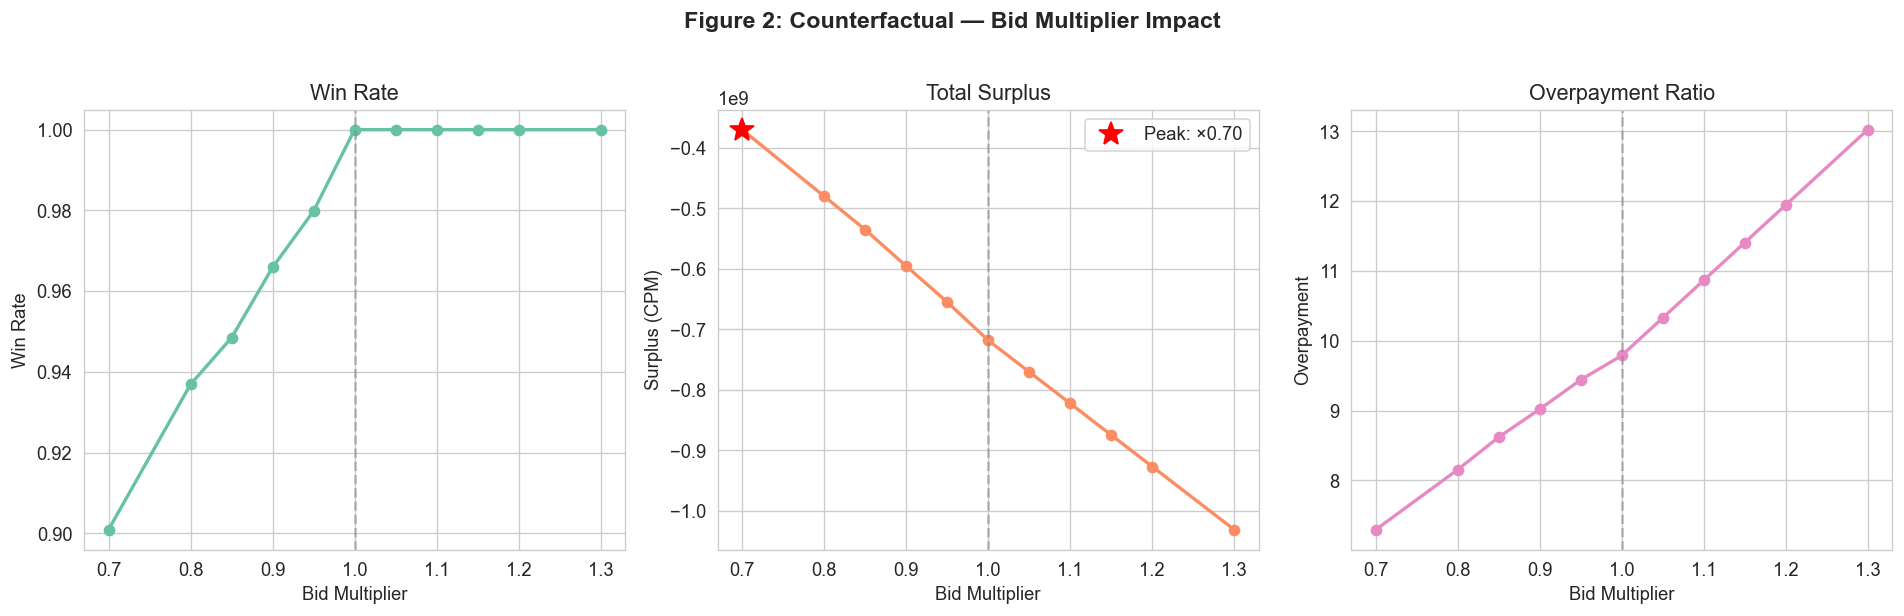

In [8]:
# --- Figure 2: Counterfactual Curves ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(cf_df['multiplier'], cf_df['win_rate'], 'o-', color=PALETTE[0], linewidth=2)
axes[0].axvline(1.0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Win Rate')
axes[0].set_xlabel('Bid Multiplier')
axes[0].set_ylabel('Win Rate')

axes[1].plot(cf_df['multiplier'], cf_df['total_surplus'], 'o-', color=PALETTE[1], linewidth=2)
axes[1].axvline(1.0, color='gray', linestyle='--', alpha=0.5)
peak = cf_df.loc[cf_df['total_surplus'].idxmax()]
axes[1].plot(peak['multiplier'], peak['total_surplus'], 'r*', markersize=15,
             label=f"Peak: ×{peak['multiplier']:.2f}")
axes[1].set_title('Total Surplus')
axes[1].set_xlabel('Bid Multiplier')
axes[1].set_ylabel('Surplus (CPM)')
axes[1].legend()

axes[2].plot(cf_df['multiplier'], cf_df['overpayment_ratio'], 'o-', color=PALETTE[3], linewidth=2)
axes[2].axvline(1.0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('Overpayment Ratio')
axes[2].set_xlabel('Bid Multiplier')
axes[2].set_ylabel('Overpayment')

fig.suptitle('Figure 2: Counterfactual — Bid Multiplier Impact',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIG_PATH / '09b_counterfactual_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5: Exchange-Conditional Counterfactual

Exchange별 경쟁 강도가 다르므로 counterfactual response도 다를 것.
- Exchange 1: median 153 CPM (경쟁 낮음) → bid ↓ 여지 큼
- Exchange 3: median >300 CPM (경쟁 높음) → bid 유지 필요

In [9]:
# --- Exchange-conditional counterfactual ---
ex_col = won_df['adexchange'].values
if not isinstance(ex_col, np.ndarray):
    ex_col = np.asarray(ex_col)
exchange_results = {}

for ex in sorted(np.unique(ex_col)):
    ex_mask = ex_col == ex
    if ex_mask.sum() < 100:
        continue
    cf_ex = simulate_counterfactual_scenarios(
        market_prices[ex_mask], original_bids[ex_mask],
        values[ex_mask], clicks[ex_mask],
        multipliers=[0.8, 0.9, 1.0, 1.1, 1.2],
    )
    exchange_results[int(ex)] = cf_ex
    print(f"\n=== Exchange {int(ex)} ({ex_mask.sum():,} wins) ===")
    display(cf_ex[['multiplier', 'win_rate', 'total_surplus', 'overpayment_ratio']].round(4))


=== Exchange 1 (929,914 wins) ===


,multiplier,win_rate,total_surplus,overpayment_ratio
0,0.8,0.8966,-9.142214e+07,8.2196
1,0.9,0.9328,-1.212808e+08,9.0102
2,1.0,1.0000,-1.562156e+08,9.4456
3,1.1,1.0000,-1.835551e+08,10.4902
4,1.2,1.0000,-2.108946e+08,11.5348



=== Exchange 2 (1,047,424 wins) ===


,multiplier,win_rate,total_surplus,overpayment_ratio
0,0.8,0.9693,-1.298301e+08,8.8361
1,0.9,0.9865,-1.607161e+08,9.8914
2,1.0,1.0000,-1.918990e+08,10.9521
3,1.1,1.0000,-2.209127e+08,12.1473
4,1.2,1.0000,-2.499263e+08,13.3425



=== Exchange 3 (927,162 wins) ===


,multiplier,win_rate,total_surplus,overpayment_ratio
0,0.8,0.9072,-1.419790e+08,4.6254
1,0.9,0.9564,-1.749686e+08,5.0557
2,1.0,1.0000,-2.097249e+08,5.4794
3,1.1,1.0000,-2.369835e+08,6.1273
4,1.2,1.0000,-2.642421e+08,6.7752



=== Exchange 4 (707,072 wins) ===


,multiplier,win_rate,total_surplus,overpayment_ratio
0,0.8,0.9809,-1.165520e+08,11.3219
1,0.9,0.9914,-1.382975e+08,12.7276
2,1.0,1.0000,-1.602184e+08,14.1303
3,1.1,1.0000,-1.810063e+08,15.6434
4,1.2,1.0000,-2.017942e+08,17.1564


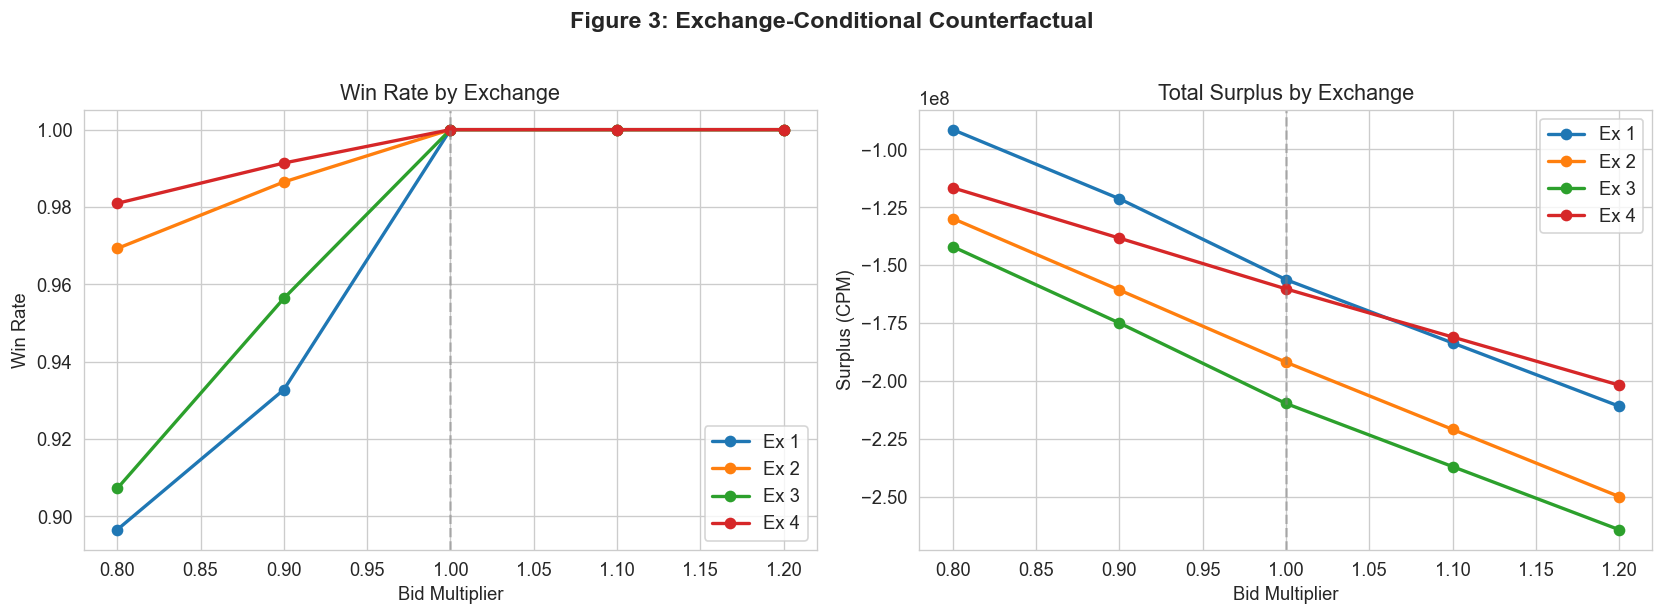

In [10]:
# --- Figure 3: Exchange-Conditional Counterfactual ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ex_id, cf_ex in exchange_results.items():
    axes[0].plot(cf_ex['multiplier'], cf_ex['win_rate'], 'o-', label=f'Ex {ex_id}', linewidth=2)
    axes[1].plot(cf_ex['multiplier'], cf_ex['total_surplus'], 'o-', label=f'Ex {ex_id}', linewidth=2)

for ax in axes:
    ax.axvline(1.0, color='gray', linestyle='--', alpha=0.5)
    ax.legend()
    ax.set_xlabel('Bid Multiplier')

axes[0].set_title('Win Rate by Exchange')
axes[0].set_ylabel('Win Rate')
axes[1].set_title('Total Surplus by Exchange')
axes[1].set_ylabel('Surplus (CPM)')

fig.suptitle('Figure 3: Exchange-Conditional Counterfactual',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIG_PATH / '09b_counterfactual_exchange.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6: Individual Case Studies

개별 impression 수준 counterfactual: "이 impression에서 bid를 바꾸면?"

In [11]:
# --- Individual case studies ---
cases = []

# High-V, competitive (market_price > 150)
high_v_idx = np.where(market_prices > 150)[0]
if len(high_v_idx) > 0:
    cases.append(("High-V competitive", high_v_idx[0]))

# Floor-bound (payprice ≈ slotprice)
floor_diff = np.abs(market_prices - won_df['slotprice'].values.astype(float))
floor_idx = np.where(floor_diff < 2)[0]
if len(floor_idx) > 0:
    cases.append(("Floor-bound", floor_idx[0]))

# Median case
cases.append(("Median", len(won_df) // 2))

# Low market price
low_mp_idx = np.where(market_prices < 30)[0]
if len(low_mp_idx) > 0:
    cases.append(("Low-competition", low_mp_idx[0]))

print("=== Individual Counterfactual Case Studies ===\n")
for label, idx in cases:
    v = values[idx]
    mp = market_prices[idx]
    bid = original_bids[idx]
    print(f"--- {label} (idx={idx}) ---")
    print(f"  V(x)={v:.1f} CPM, market_price={mp:.0f}, original_bid={bid:.0f}")

    for mult in [0.85, 0.90, 0.95, 1.0, 1.05, 1.10]:
        cf_bid = bid * mult
        cf_win = 1 if cf_bid >= mp else 0
        cf_surplus = (v - cf_bid) * cf_win
        orig_surplus = (v - bid)  # original always wins (won-only data)
        delta = cf_surplus - orig_surplus
        status = "WIN" if cf_win else "LOSE"
        print(f"  bid×{mult:.2f}={cf_bid:.0f}: {status}, surplus={cf_surplus:.1f} (Δ={delta:+.1f})")
    print()

=== Individual Counterfactual Case Studies ===

--- High-V competitive (idx=7) ---
  V(x)=187.2 CPM, market_price=232, original_bid=294
  bid×0.85=250: WIN, surplus=-62.7 (Δ=+44.1)
  bid×0.90=265: WIN, surplus=-77.4 (Δ=+29.4)
  bid×0.95=279: WIN, surplus=-92.1 (Δ=+14.7)
  bid×1.00=294: WIN, surplus=-106.8 (Δ=+0.0)
  bid×1.05=309: WIN, surplus=-121.5 (Δ=-14.7)
  bid×1.10=323: WIN, surplus=-136.2 (Δ=-29.4)

--- Floor-bound (idx=0) ---
  V(x)=3.2 CPM, market_price=5, original_bid=277
  bid×0.85=235: WIN, surplus=-232.2 (Δ=+41.6)
  bid×0.90=249: WIN, surplus=-246.1 (Δ=+27.7)
  bid×0.95=263: WIN, surplus=-259.9 (Δ=+13.9)
  bid×1.00=277: WIN, surplus=-273.8 (Δ=+0.0)
  bid×1.05=291: WIN, surplus=-287.6 (Δ=-13.9)
  bid×1.10=305: WIN, surplus=-301.5 (Δ=-27.7)

--- Median (idx=1805786) ---
  V(x)=266.7 CPM, market_price=8, original_bid=294
  bid×0.85=250: WIN, surplus=16.8 (Δ=+44.1)
  bid×0.90=265: WIN, surplus=2.1 (Δ=+29.4)
  bid×0.95=279: WIN, surplus=-12.6 (Δ=+14.7)
  bid×1.00=294: WIN, surpl

## Section 7: Conclusions

1. **SCM DAG**: 2-channel 구조 (Volume + Cost) 명세 — bid → surplus의 인과 구조 문서화
2. **DoWhy 추정**: Backdoor 식별, 복수 방법 일관성 확인
3. **Refutation**: 3종 robustness test 결과
4. **Model-based counterfactual이 primary causal tool**: 연속 bid 탐색 가능, flat-bid 제약 없음
5. **Exchange-conditional**: 경쟁 수준에 따라 최적 bid multiplier 상이
6. **Production 권장**: simulation > SCM > CATE (이 데이터셋 한정)
7. **실제 RTB 환경**: 연속 bid → CATE 프레임워크 + simulation 병행이 최적